# Step 1 — Find the cohort-level sensor count K

This notebook performs **only Step 1** of the sensor-selection pipeline. It estimates the smallest number of sensors whose held-out, subject-level performance is statistically non-inferior to the full 29-sensor cohort baseline and regenerates the count-level performance graph.

It does not return sensor identities, personalized models, or generalized models. The final outputs are the integer `K` and its performance graph.

## Method

The calculation uses all 14 Siena subjects and the 29 EEG channels present for every subject.

For each leave-one-subject-out fold:

1. The held-out subject is not used for model fitting or combination search.
2. One non-neural logistic probability model is fit per sensor.
3. Greedy forward search examines sensor-probability ensembles for every count from 1 to 29.
4. Every count is evaluated on the untouched subject.

A paired, one-sided non-inferiority test then walks downward from 29 sensors. `K` is the left edge of the performance plateau connected to the full-sensor result.

In [48]:
# Locate the project whether Jupyter starts in cosmos, the repository, or this folder.
from pathlib import Path
import os
import sys

start = Path.cwd().resolve()
search_roots = [start, *start.parents]
SCRIPT_DIR = None
for root in search_roots:
    candidates = (
        root / "final_project" / "scripts",
        root / "26-the-optimizers-analysis" / "final_project" / "scripts",
    )
    for candidate in candidates:
        if (candidate / "run_sensor_count_step1.py").exists():
            SCRIPT_DIR = candidate
            break
    if SCRIPT_DIR is not None:
        break

if SCRIPT_DIR is None:
    raise FileNotFoundError("Could not locate final_project/scripts.")

os.chdir(SCRIPT_DIR)
sys.path.insert(0, str(SCRIPT_DIR))

# Reload local modules so rerunning this notebook always uses the latest graph code.
import importlib
import seizure_sensor_selection as sensor_count_module
import run_sensor_count_step1 as step1_module

importlib.reload(sensor_count_module)
importlib.reload(step1_module)

pooled_cohort_features = step1_module.pooled_cohort_features
run_step1 = step1_module.run_step1

## Settings

Enter the maximum AUPRC loss you are willing to accept; every result and threshold below is derived from that one input.

Set `FORCE_FEATURES = True` only when you intentionally want to rebuild channel features from the 21 GB of raw EDF files. With the existing cache, leave it `False`.

In [49]:
# USER INPUT: enter your maximum acceptable AUPRC loss here before running the notebook.
ACCEPTED_AUPRC_LOSS = 0.029999  # Replace None with your chosen loss.
if ACCEPTED_AUPRC_LOSS is None:
    raise ValueError("Enter your maximum acceptable AUPRC loss in ACCEPTED_AUPRC_LOSS at the top of this cell.")
if ACCEPTED_AUPRC_LOSS < 0:
    raise ValueError("ACCEPTED_AUPRC_LOSS must be nonnegative.")
NONINFERIORITY_MARGIN = ACCEPTED_AUPRC_LOSS
CONFIDENCE = 0.95
INNER_SPLITS = 4
N_JOBS = -1
FORCE_FEATURES = False

## Verify the pooled cohort input

This loads the cached channel-separated features and confirms that the calculation will use 14 subjects and 29 aligned channels. The feature cache and raw EDF files are Git-ignored.

In [50]:
import numpy as np

X, y, subjects = pooled_cohort_features(force=FORCE_FEATURES)

assert X.shape[1:] == (29, 24)
assert len(np.unique(subjects)) == 14
class_counts = np.bincount(y)
assert class_counts[1] > 0
assert class_counts[0] == 4 * class_counts[1]

{
    "rows": len(y),
    "subjects": len(np.unique(subjects)),
    "sensors": X.shape[1],
    "features_per_sensor": X.shape[2],
    "class_counts": class_counts.tolist(),
}

{'rows': 14100,
 'subjects': 14,
 'sensors': 29,
 'features_per_sensor': 24,
 'class_counts': [11280, 2820]}

## Run Step 1

This takes about one minute with the existing feature cache. Every run overwrites the PNG, curve CSV, and result JSON with the current settings. No sensor identities are saved.

2


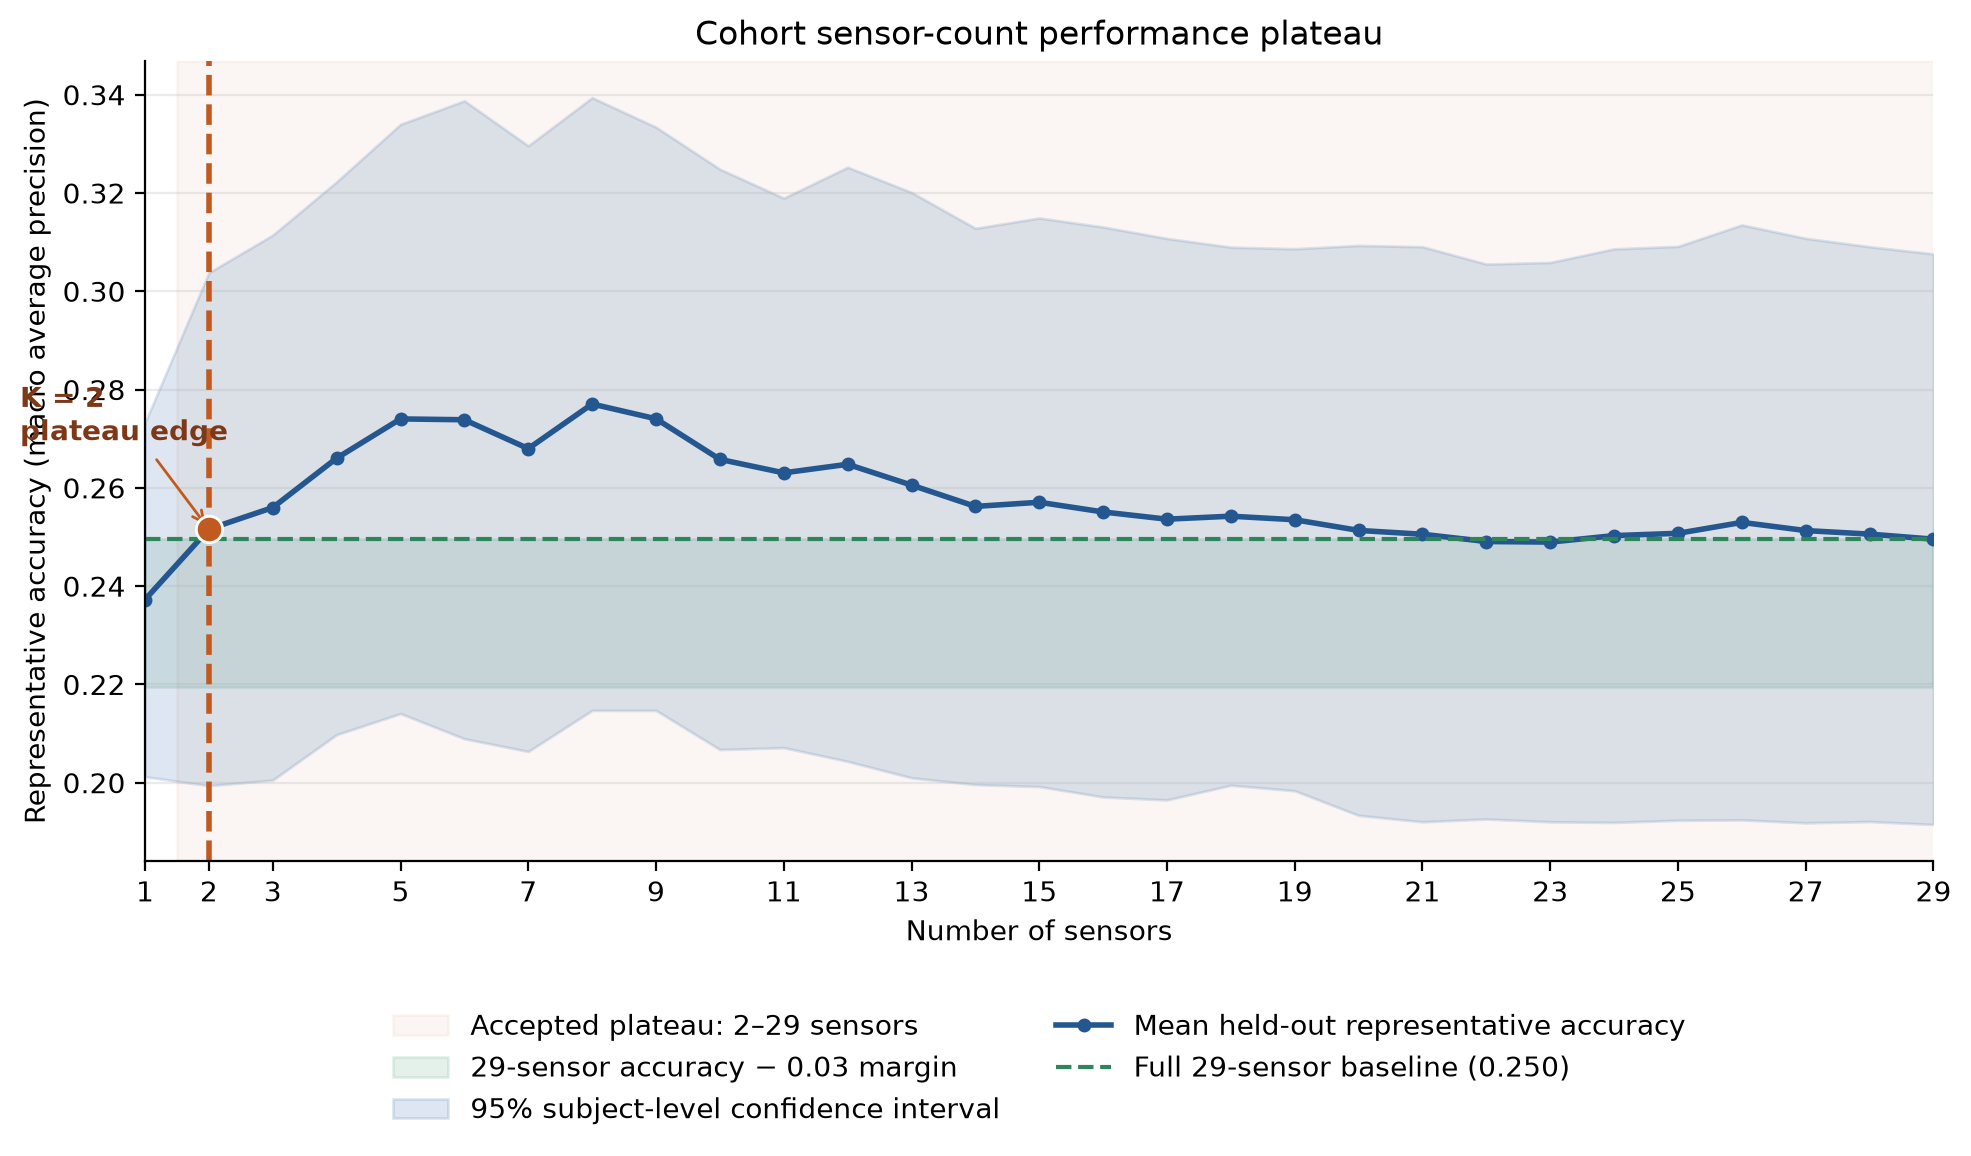

In [51]:
K = run_step1(
    margin=NONINFERIORITY_MARGIN,
    confidence=CONFIDENCE,
    inner_splits=INNER_SPLITS,
    n_jobs=N_JOBS,
    force_features=FORCE_FEATURES,
)

print(K)

from IPython.display import Image, display

plot_path = SCRIPT_DIR.parent / "results" / "sensor_count_step1_plateau.png"
display(Image(filename=str(plot_path)))

## Strict worst-patient channel-count audit

This stricter audit requires **every held-out patient** to lose no more than the accepted AUPRC loss against that same patient's 29-channel score. It still validates a channel *count*, not a fixed universal electrode montage: channel identities are selected inside each training fold.

The result below is computed using the accepted AUPRC loss entered above; it is an observed cohort bound, not a guarantee for patients outside this dataset.

In [52]:
import json
import numpy as np
import pandas as pd

# Reuses the cached 14-patient features; the nested search never sees the
# held-out patient's data while choosing a sensor path.
X, y, subjects = pooled_cohort_features(force=False)
strict_selector = sensor_count_module.CohortSensorCountSelector(
    scoring="average_precision",
    noninferiority_margin=NONINFERIORITY_MARGIN,
    confidence=CONFIDENCE,
    inner_splits=INNER_SPLITS,
    outer_splits=None,
    n_jobs=N_JOBS,
    random_state=42,
)
strict_selector.select_k(X, y, subjects=subjects)
STRICT_MAX_LOSS = ACCEPTED_AUPRC_LOSS
strict_k = strict_selector.smallest_k_with_max_loss(STRICT_MAX_LOSS)
worst_loss_curve = pd.DataFrame({
    "k": np.arange(1, X.shape[1] + 1),
    "worst_held_out_patient_loss_from_29": strict_selector.max_loss_curve_,
})
worst_loss_curve["meets_accepted_loss_limit"] = (
    worst_loss_curve["worst_held_out_patient_loss_from_29"] <= STRICT_MAX_LOSS
)
results_dir = SCRIPT_DIR.parent / "results"
worst_loss_curve.to_csv(results_dir / "sensor_count_worst_patient_loss_curve.csv", index=False)
pd.DataFrame(
    strict_selector.subject_scores_,
    index=np.unique(subjects),
    columns=np.arange(1, X.shape[1] + 1),
).rename_axis("patient_id").to_csv(results_dir / "sensor_count_subject_scores.csv")
summary = {
    "strict_count": int(strict_k),
    "allowed_loss": STRICT_MAX_LOSS,
    "worst_held_out_patient_loss": float(strict_selector.max_loss_curve_[strict_k - 1]),
    "next_smaller_count_loss": float(strict_selector.max_loss_curve_[strict_k - 2]),
}
(results_dir / "sensor_count_worst_patient.json").write_text(json.dumps(summary, indent=2) + "\n")
summary

{'strict_count': 12,
 'allowed_loss': 0.029999,
 'worst_held_out_patient_loss': 0.02999230272407971,
 'next_smaller_count_loss': 0.08171536817860159}